# HPDM097 Assignment 2

## Iteration 7: Range of rehab ward beds for assessing p(delay) (Gemini)

This is the 7th iteration to the code. Here we add a function to assess the p(delay) for a range of rehab beds available and compare it to the range of acute beds

Prompt and response: https://gemini.google.com/share/a6162b05b09a

## Prompt:
Using the iterative approach and adding to code above, the next objective is the same as we did for the acute beds but for the rehab beds, real-life resource is 12 but please use a range of 0-26 for the rehab beds and keep the previous analysis and output for the acute stroke beds as well so we can compare both. Arrange the two graphs vertically one on top of the other instead of horizontally.

## Response
This is a great continuation. By applying the exact same logic to the rehab ward, we can evaluate the system's choke points holistically. If you fix the acute unit without addressing rehab capacity, you risk creating a bottleneck further downstream.

To achieve this, I've made the following changes to our existing model:

Rehab Audit Logic: Added self.daily_rehab_occupancy to track the unconstrained occupancy of the rehab beds simultaneously with the acute beds during the daily_audit process.

Rehab Output Table: Added an execution block to calculate and print the statistical summary and the Erlang B step table specifically for the rehab ward data.

Stacked Matplotlib Figure: Updated plot_tradeoff_curve to accept both data sets and construct a figure with two subplots (nrows=2, ncols=1), stacking the Acute chart on top of the Rehab chart for easy comparison.

Here is the updated code:

--- Running Simulation (3 Year Warm-up + 10 Year Run) ---

--- Post-Warmup P(delay) Analysis for ACUTE Beds ---
Mean Unconstrained Acute Occupancy: 8.17 beds

Capacity | P(delay) | % Delayed
---------------------------------
      0  |  1.0000  |  100.00%
      1  |  0.8889  |   88.89%
      2  |  0.7568  |   75.68%
      3  |  0.6574  |   65.74%
      4  |  0.6412  |   64.12%
      5  |  0.5090  |   50.90%
      6  |  0.4233  |   42.33%
      7  |  0.3285  |   32.85%
      8  |  0.2440  |   24.40%
      9  |  0.1727  |   17.27%
     10  |  0.1371  |   13.71%
     11  |  0.0817  |    8.17%
     12  |  0.0592  |    5.92%
     13  |  0.0333  |    3.33%
     14  |  0.0206  |    2.06%
     15  |  0.0091  |    0.91%
     16  |  0.0066  |    0.66%
     17  |  0.0008  |    0.08%
     18  |  0.0003  |    0.03%
     19  |  0.0005  |    0.05%
     20  |  0.0003  |    0.03%
     21  |  0.0000  |    0.00%
     22  |  0.0000  |    0.00%
     23  |  0.0000  |    0.00%
     24  |  0.0000  |    0.00%


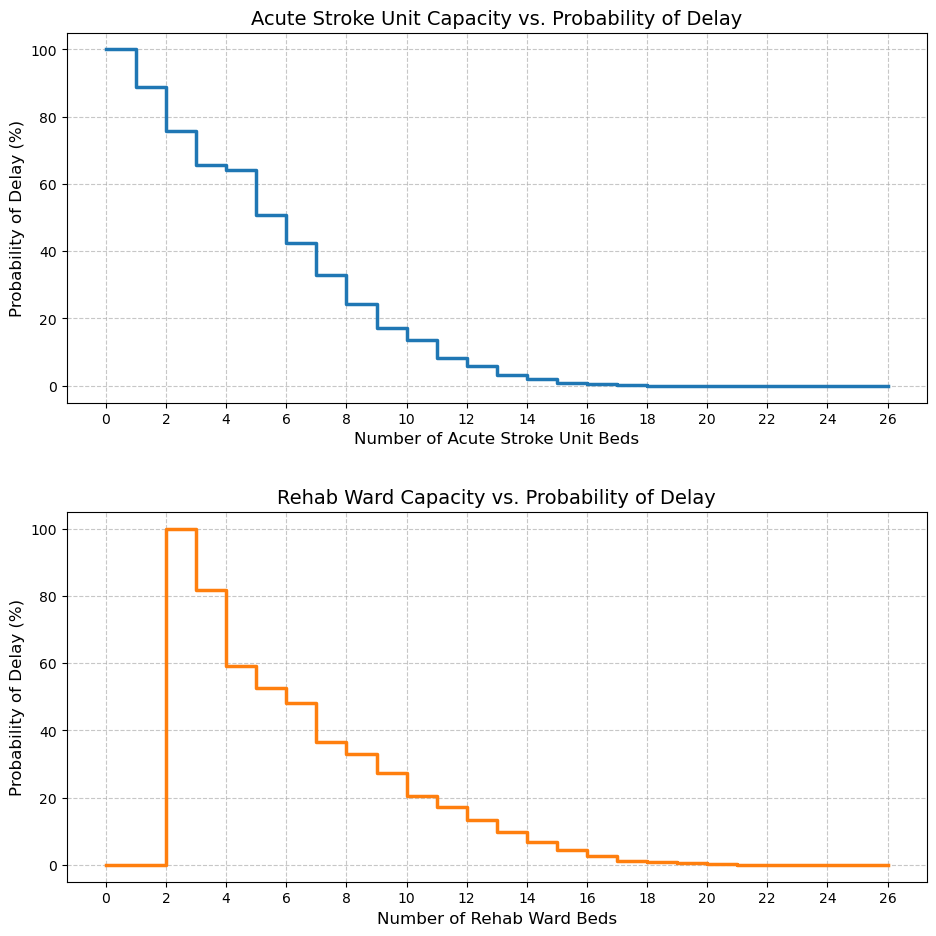

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self):
        self.random_seed = 42
        
        # Simulation Runtime Parameters (Days)
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        # Unconstrained capacities to measure offered load
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        # Capacities to evaluate for the trade-off curves (0 to 26)
        self.capacity_eval_range = range(0, 27) 
        
        self.acute_inter_arrival_means = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        
        self.rehab_inter_arrival_means = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.acute_bed_request_time = None
        self.acute_bed_acquire_time = None
        self.acute_length_of_stay = None
        self.acute_discharge_time = None
        self.rehab_destination = None
        self.rehab_bed_request_time = None
        self.rehab_bed_acquire_time = None
        self.rehab_length_of_stay = None
        self.rehab_discharge_time = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        # Lists to store daily occupancy for both wards
        self.daily_acute_occupancy = []
        self.daily_rehab_occupancy = []
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        """Waits for the warm-up period, then wakes up daily to record steady-state occupancy."""
        yield self.env.timeout(self.scenario.warm_up_days)
        trace(f"Day {self.env.now:06.2f} | Warm-up complete. Starting daily occupancy audits.")
        
        while True:
            # Audit both Acute and Rehab occupancy simultaneously
            self.daily_acute_occupancy.append(len(self.acute_beds.users))
            self.daily_rehab_occupancy.append(len(self.rehab_beds.users))
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        patient.acute_bed_request_time = self.env.now
        
        with self.acute_beds.request() as req:
            yield req
            patient.acute_bed_acquire_time = self.env.now
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            patient.acute_length_of_stay = los
            yield self.env.timeout(los)
            patient.acute_discharge_time = self.env.now
            
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        patient.rehab_bed_request_time = self.env.now
        
        with self.rehab_beds.request() as req:
            yield req
            patient.rehab_bed_acquire_time = self.env.now
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            patient.rehab_length_of_stay = los
            yield self.env.timeout(los)
            patient.rehab_discharge_time = self.env.now

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    """Calculates Erlang P(delay) for a range of capacities based on steady-state occupancy."""
    if not occupancy_data:
        return {}
        
    max_eval_capacity = max(capacity_range)
    max_actual_occupancy = max(occupancy_data)
    array_size = max(max_eval_capacity, max_actual_occupancy) + 1
    
    counts = np.zeros(array_size)
    for occ in occupancy_data:
        counts[occ] += 1
        
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    
    results = {}
    for n in capacity_range:
        p_n = pdf[n]
        p_le_n = cdf[n]
        p_delay = p_n / p_le_n if p_le_n > 0 else 0.0
        results[n] = p_delay
        
    return results

def plot_tradeoff_curves(acute_results, rehab_results):
    """Generates a vertically stacked plot of the P(delay) curves for Acute and Rehab wards."""
    beds = list(acute_results.keys())
    
    # Convert probabilities to percentages for the y-axis
    acute_pct = [val * 100 for val in acute_results.values()] 
    rehab_pct = [val * 100 for val in rehab_results.values()] 
    
    # Create a figure with 2 subplots vertically
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
    
    # --- Top Plot: Acute Beds ---
    ax1.step(beds, acute_pct, where='post', color='#1f77b4', linewidth=2.5)
    ax1.set_title('Acute Stroke Unit Capacity vs. Probability of Delay', fontsize=14)
    ax1.set_xlabel('Number of Acute Stroke Unit Beds', fontsize=12)
    ax1.set_ylabel('Probability of Delay (%)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xticks(beds[::2])
    ax1.set_ylim(-5, 105)
    
    # --- Bottom Plot: Rehab Beds ---
    ax2.step(beds, rehab_pct, where='post', color='#ff7f0e', linewidth=2.5)
    ax2.set_title('Rehab Ward Capacity vs. Probability of Delay', fontsize=14)
    ax2.set_xlabel('Number of Rehab Ward Beds', fontsize=12)
    ax2.set_ylabel('Probability of Delay (%)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_xticks(beds[::2])
    ax2.set_ylim(-5, 105)
    
    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    scenario = Scenario()
    env = simpy.Environment()
    model = StrokeUnit(env, scenario)
    
    print(f"--- Running Simulation ({scenario.warm_up_days//365} Year Warm-up + {scenario.run_days//365} Year Run) ---")
    model.run_simulation()
    
    total_sim_time = scenario.warm_up_days + scenario.run_days
    env.run(until=total_sim_time)
    
    # Process Acute Data
    print(f"\n--- Post-Warmup P(delay) Analysis for ACUTE Beds ---")
    print(f"Mean Unconstrained Acute Occupancy: {np.mean(model.daily_acute_occupancy):.2f} beds\n")
    acute_p_delay_results = calculate_p_delay_curve(model.daily_acute_occupancy, scenario.capacity_eval_range)
    print("Capacity | P(delay) | % Delayed")
    print("---------------------------------")
    for beds, p_delay in acute_p_delay_results.items():
        print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%")
        
    # Process Rehab Data
    print(f"\n--- Post-Warmup P(delay) Analysis for REHAB Beds ---")
    print(f"Mean Unconstrained Rehab Occupancy: {np.mean(model.daily_rehab_occupancy):.2f} beds\n")
    rehab_p_delay_results = calculate_p_delay_curve(model.daily_rehab_occupancy, scenario.capacity_eval_range)
    print("Capacity | P(delay) | % Delayed")
    print("---------------------------------")
    for beds, p_delay in rehab_p_delay_results.items():
        print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%")
        
    print("\nGenerating Matplotlib visualization...")
    plot_tradeoff_curves(acute_p_delay_results, rehab_p_delay_results)